<a href="https://colab.research.google.com/github/scottac1111/Alex-Scott-Repository/blob/main/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Alex Scott

*NEUR 265*

**3/6/26**

In [6]:
#import pandas, matplotlib and scipy

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [8]:
#load patch_seq_expanded data as a Pandas dataframe

url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq = pd.read_csv (url, delimiter=',')

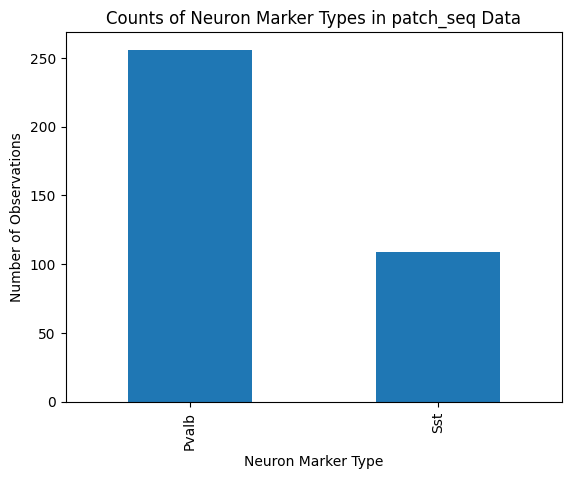

In [9]:
# Create a bar graph showing how many observations there are for each neuron marker type

patch_seq['Marker'].value_counts().plot(kind='bar')

plt.xlabel('Neuron Marker Type')
plt.ylabel('Number of Observations')
plt.title('Counts of Neuron Marker Types in patch_seq Data')
plt.show()

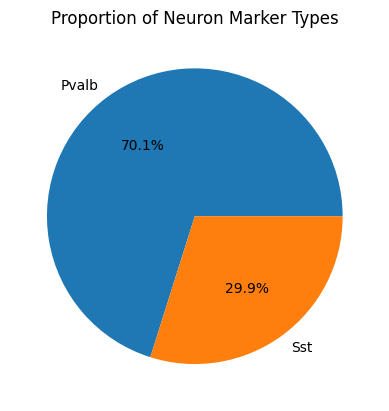

In [10]:
# Create a pie chart

patch_seq['Marker'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.ylabel('')
plt.title('Proportion of Neuron Marker Types')
plt.show()

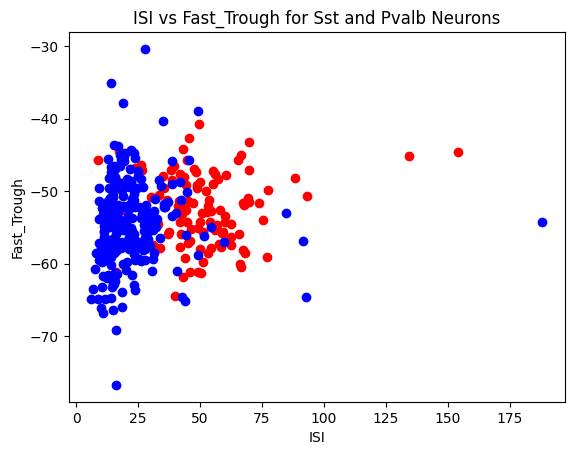

In [11]:
# Create a scatter plot of ISI (x-axis) vs Fast_Trough (y-axis), coloring Sst neurons red and Pvalb neurons blue

for i, row in patch_seq.iterrows():

    if row['Marker'] == 'Sst':
        plt.scatter(row['ISI'], row['Fast_Trough'], color='red')

    elif row['Marker'] == 'Pvalb':
        plt.scatter(row['ISI'], row['Fast_Trough'], color='blue')

plt.xlabel('ISI')
plt.ylabel('Fast_Trough')
plt.title('ISI vs Fast_Trough for Sst and Pvalb Neurons')
plt.show()

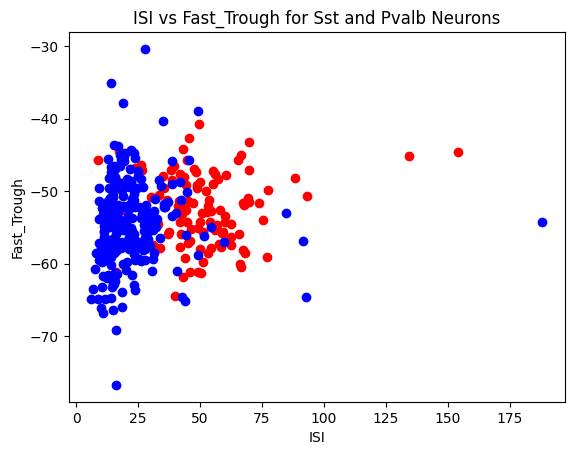

In [12]:
# Define a function called patchScatter() that generates and displays the ISI vs Fast_Trough scatter plot

def patchScatter():

    for i, row in patch_seq.iterrows():

        if row['Marker'] == 'Sst':
            plt.scatter(row['ISI'], row['Fast_Trough'], color='red')

        elif row['Marker'] == 'Pvalb':
            plt.scatter(row['ISI'], row['Fast_Trough'], color='blue')

    plt.xlabel('ISI')
    plt.ylabel('Fast_Trough')
    plt.title('ISI vs Fast_Trough for Sst and Pvalb Neurons')
    plt.show()

# Call the function to display the scatter plot
patchScatter()

In [14]:
# Calculate summary statistics (mean, SD, range, etc.) for Fast_Trough grouped by neuron marker

patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


#Describe the difference in means between Sst and Pvalb neurons

It appears that Pvalb neurons tend to have a more negative Fast_Trough mean compared to Sst neurons. Because Fast_Trough represents the undershoot following an action potential, this shows that Pvalb neurons experience a stronger (more negative) afterhyperpolarization than Sst neurons.

In [15]:
# Calculate the skewness of the Fast_Trough values for each neuron marker group
patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


#Interpret Fast_Trough skewness

Pvalb's skewness is roughly .195 while Sst's skewness is .00125. Since both values fall in between 0.5 and -0.5, this means that the Fast_Trough distributions for both neuron types are approximately normal and do not show strong skewness (so basically the graph would look pretty much symmetrical with the values distributed evenly around their means for both groups).

In [17]:
# Calculate the skewness of the ISI values
patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


#Interpret ISI Skewness

The skewness values for the ISI column are 5.596 for Pvalb neurons and 1.858 for Sst neurons. Because both values are greater than 0.5, the ISI distributions for both neuron types are positively skewed rather than normally distributed. The majority of values will be clustered on the left (lower) side, creating a long, trailing tail that extends toward the higher, positive values on the right. The skewness is much stronger for Pvalb neurons, suggesting a greater presence of extreme ISI values in that group.

In [18]:
# Separate the dataset into two groups based on neuron marker type
sst_neurons = patch_seq[patch_seq['Marker'] == 'Sst']
pvalb_neurons = patch_seq[patch_seq['Marker'] == 'Pvalb']

# Perform an independent samples t-test comparing Fast_Trough values between the two neuron types
stats.ttest_ind(sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

#Describe results of the Fast_Trough t-test

Since the p-value is 0.0017 which is less than 0.05, this means that the difference between the groups is statistically significant, indicating that the undershoot voltage differs between the two neuron types.

In [19]:
# Remove missing ISI values for each neuron group
sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()

# Perform an independent samples t-test comparing ISI values between the two neuron types
stats.ttest_ind(sst, pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

#Describe results of ISI t-test

Since the p-value = 2.69 is > 0.05, the ISI values are not significantly different.